In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_style("whitegrid")

In [50]:
DATASET_PATH = 'train.csv'
DATASET_PATH_TEST = 'test.csv'

In [51]:
df = pd.read_csv(DATASET_PATH)
df.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,B,B,33,7976,5,NaN,0,11,B,184966.930730
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,B,B,46,10309,1,240.0,1,16,B,300009.450063
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,B,B,34,7759,0,229.0,1,3,B,220925.908524
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,B,B,23,5735,3,1084.0,0,5,B,175616.227217
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,B,B,35,5776,1,2078.0,2,4,B,150226.531644
5,12915,59,3.0,80.384479,46.683720,12.0,5,17.0,2011,0.309479,B,B,35,7715,4,990.0,0,6,B,215898.447742
6,14549,154,2.0,62.254114,37.160377,7.0,3,5.0,1960,0.460556,B,B,20,4386,14,NaN,1,5,B,296021.204377
7,11993,74,2.0,80.312926,NaN,0.0,14,0.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B,221244.156664
8,5172,1,2.0,64.511437,NaN,1.0,9,17.0,1977,0.007122,B,B,1,264,0,NaN,0,1,B,229102.795999
9,8649,23,1.0,46.461409,18.915552,8.0,13,17.0,2014,0.075779,B,B,6,1437,3,NaN,0,2,B,95380.220993


In [52]:
df.shape

(10000, 20)

In [53]:
df.columns

Index(['Id', 'DistrictId', 'Rooms', 'Square', 'LifeSquare', 'KitchenSquare',
       'Floor', 'HouseFloor', 'HouseYear', 'Ecology_1', 'Ecology_2',
       'Ecology_3', 'Social_1', 'Social_2', 'Social_3', 'Healthcare_1',
       'Helthcare_2', 'Shops_1', 'Shops_2', 'Price'],
      dtype='object')

In [54]:
df.dtypes

Id                 int64
DistrictId         int64
Rooms            float64
Square           float64
LifeSquare       float64
KitchenSquare    float64
Floor              int64
HouseFloor       float64
HouseYear          int64
Ecology_1        float64
Ecology_2         object
Ecology_3         object
Social_1           int64
Social_2           int64
Social_3           int64
Healthcare_1     float64
Helthcare_2        int64
Shops_1            int64
Shops_2           object
Price            float64
dtype: object

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

In [56]:
df.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00000,10000.000000,10000.000000,10000.000000,7887.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,5202.000000,10000.000000,10000.000000,10000.000000
mean,8383.40770,50.400800,1.890500,56.315775,37.199645,6.273300,8.526700,12.609400,3.990166e+03,0.118858,24.687000,5352.157400,8.039200,1142.904460,1.319500,4.231300,214138.857399
std,4859.01902,43.587592,0.839512,21.058732,86.241209,28.560917,5.241148,6.775974,2.005003e+05,0.119025,17.532614,4006.799803,23.831875,1021.517264,1.493601,4.806341,92872.293865
min,0.00000,0.000000,0.000000,1.136859,0.370619,0.000000,1.000000,0.000000,1.910000e+03,0.000000,0.000000,168.000000,0.000000,0.000000,0.000000,0.000000,59174.778028
25%,4169.50000,20.000000,1.000000,41.774881,22.769832,1.000000,4.000000,9.000000,1.974000e+03,0.017647,6.000000,1564.000000,0.000000,350.000000,0.000000,1.000000,153872.633942
50%,8394.50000,36.000000,2.000000,52.513310,32.781260,6.000000,7.000000,13.000000,1.977000e+03,0.075424,25.000000,5285.000000,2.000000,900.000000,1.000000,3.000000,192269.644879
75%,12592.50000,75.000000,2.000000,65.900625,45.128803,9.000000,12.000000,17.000000,2.001000e+03,0.195781,36.000000,7227.000000,5.000000,1548.000000,2.000000,6.000000,249135.462171
max,16798.00000,209.000000,19.000000,641.065193,7480.592129,2014.000000,42.000000,117.000000,2.005201e+07,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.000000,23.000000,633233.466570


In [57]:
df.isna().sum()



Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare       2113
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64

In [58]:
df.isna().mean()


Id               0.0000
DistrictId       0.0000
Rooms            0.0000
Square           0.0000
LifeSquare       0.2113
KitchenSquare    0.0000
Floor            0.0000
HouseFloor       0.0000
HouseYear        0.0000
Ecology_1        0.0000
Ecology_2        0.0000
Ecology_3        0.0000
Social_1         0.0000
Social_2         0.0000
Social_3         0.0000
Healthcare_1     0.4798
Helthcare_2      0.0000
Shops_1          0.0000
Shops_2          0.0000
Price            0.0000
dtype: float64

In [59]:
df.isna().sum().sort_values(ascending=False)


Healthcare_1     4798
LifeSquare       2113
Id                  0
Ecology_3           0
Shops_2             0
Shops_1             0
Helthcare_2         0
Social_3            0
Social_2            0
Social_1            0
Ecology_2           0
DistrictId          0
Ecology_1           0
HouseYear           0
HouseFloor          0
Floor               0
KitchenSquare       0
Square              0
Rooms               0
Price               0
dtype: int64

In [60]:
df.nunique().sort_values()

Shops_2              2
Ecology_2            2
Ecology_3            2
Helthcare_2          7
Rooms                9
Shops_1             16
Social_3            30
Floor               33
HouseFloor          44
Social_1            51
KitchenSquare       58
Healthcare_1        79
HouseYear           97
Ecology_1          129
Social_2           142
DistrictId         205
LifeSquare        7887
Id               10000
Square           10000
Price            10000
dtype: int64

In [61]:
df.duplicated().sum()
df[df.duplicated()]

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price


In [62]:
numeric_cols = df.select_dtypes(include=["number"]).columns

categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

numeric_cols = numeric_cols.drop(["Id", "Price", "Helthcare_2", "Rooms", "Shops_1", ])
categorical_cols = categorical_cols.append(
    pd.Index(["Helthcare_2", "Rooms", "Shops_1"])
)


print(f"Числовые колонки ({len(numeric_cols)}):")
print(list(numeric_cols))

print(f"\nКатегориальные колонки ({len(categorical_cols)}):")
print(list(categorical_cols))


Числовые колонки (12):
['DistrictId', 'Square', 'LifeSquare', 'KitchenSquare', 'Floor', 'HouseFloor', 'HouseYear', 'Ecology_1', 'Social_1', 'Social_2', 'Social_3', 'Healthcare_1']

Категориальные колонки (6):
['Ecology_2', 'Ecology_3', 'Shops_2', 'Helthcare_2', 'Rooms', 'Shops_1']


In [63]:
def plot_numeric_distributions_with_quantile(df, numeric_cols):
    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col].dropna(), bins=100, kde=True, ax=axes[0])
        axes[0].set_title(f"{col} (full range)")

        q_high = df[col].quantile(0.97)
        sns.histplot(
            df[col][df[col] <= q_high].dropna(),
            bins=100,
            kde=True,
            ax=axes[1]
        )
        axes[1].set_title(f"{col} (<= 97 percentile)")

        plt.tight_layout()
        plt.show()


In [77]:
def plot_numeric_distributions(df, numeric_cols):
    for col in numeric_cols:
        plt.figure(figsize=(6, 4))

        sns.histplot(df[col].dropna(), bins=100, kde=True)
        plt.title(f"{col} (full range)")
        plt.xlabel(col)
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()


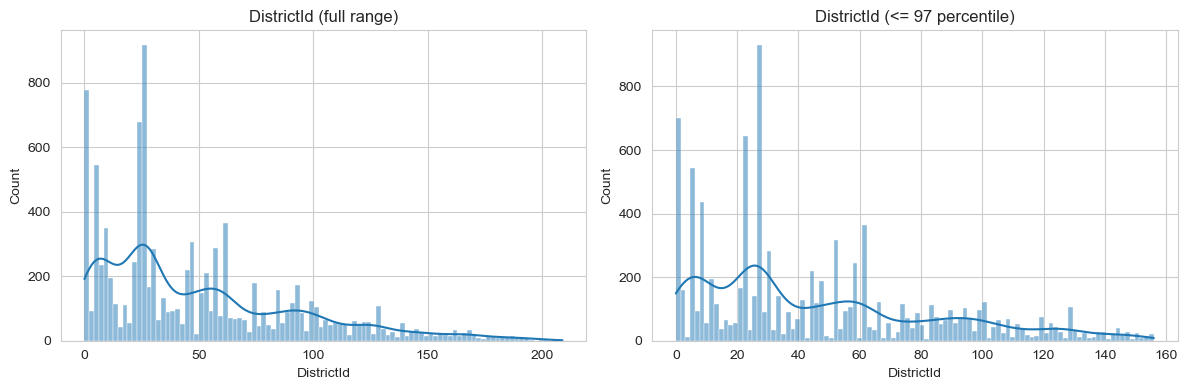

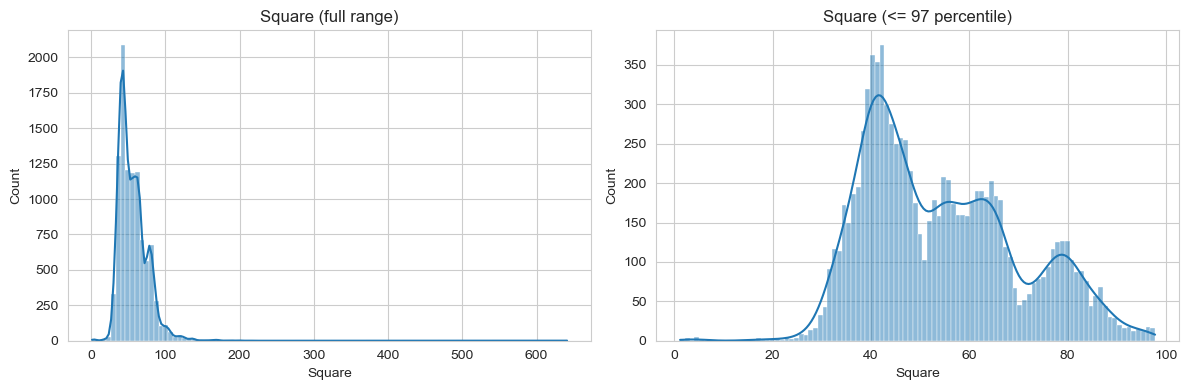

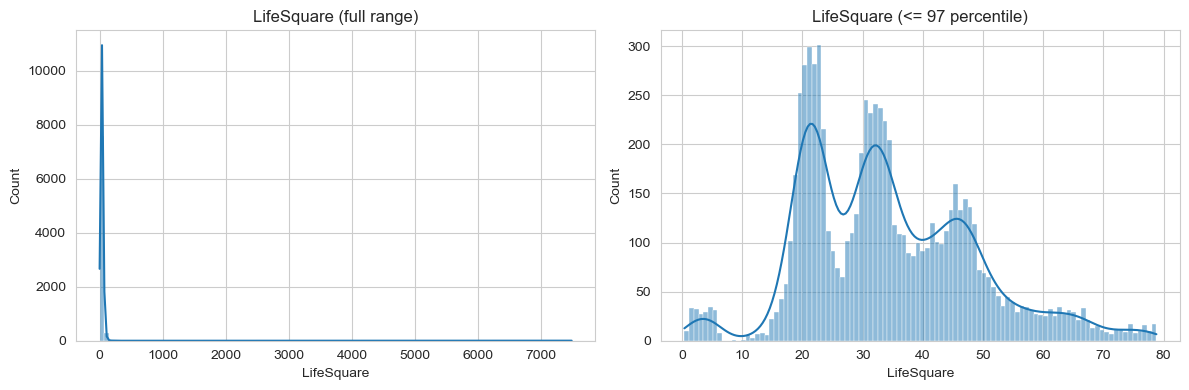

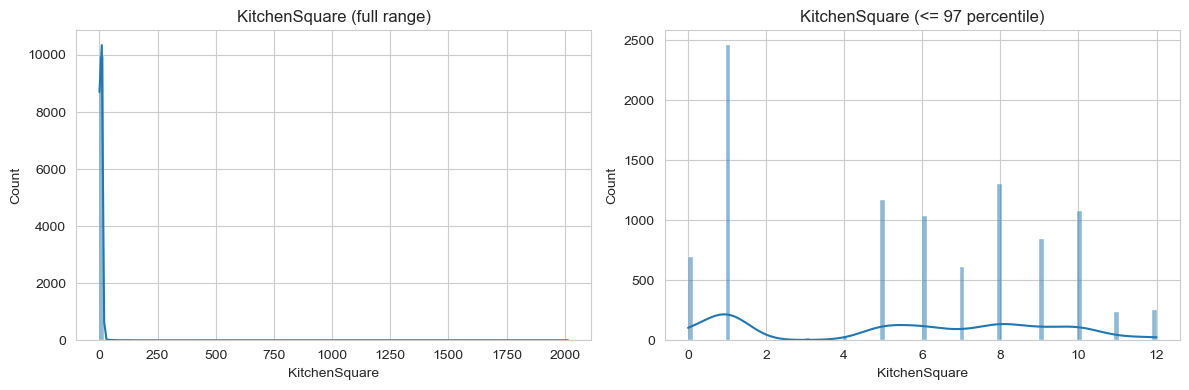

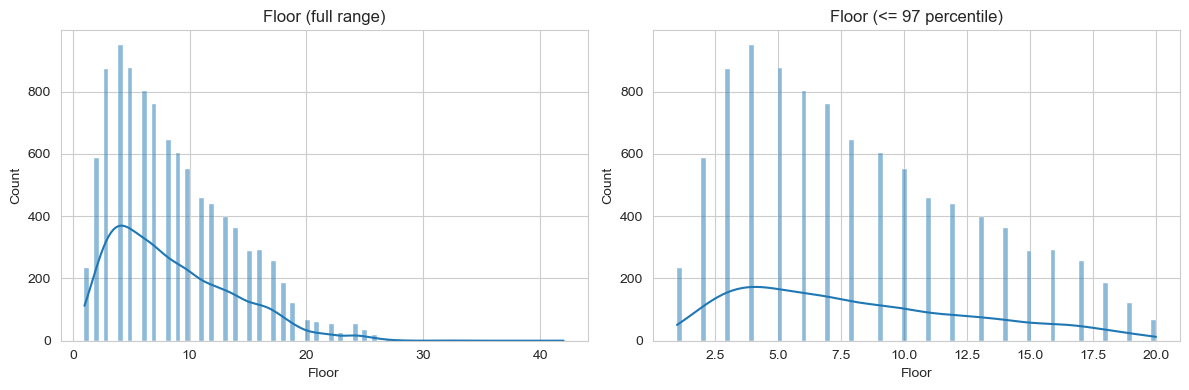

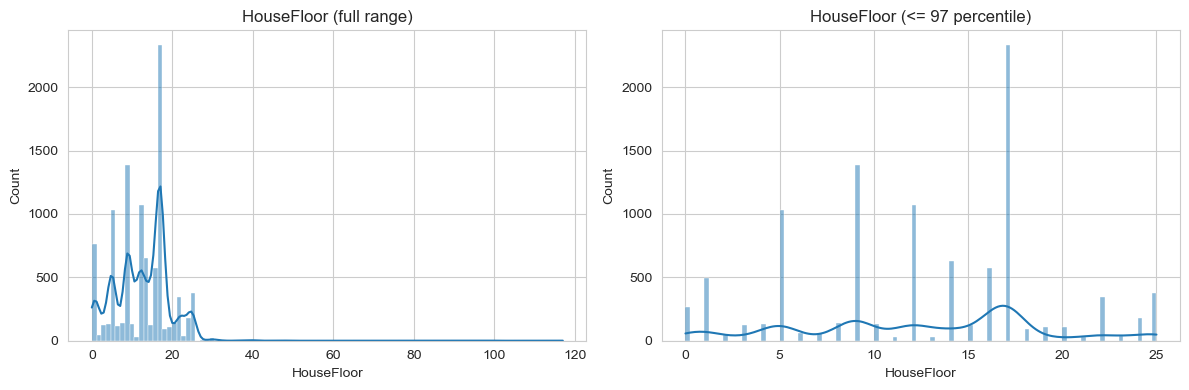

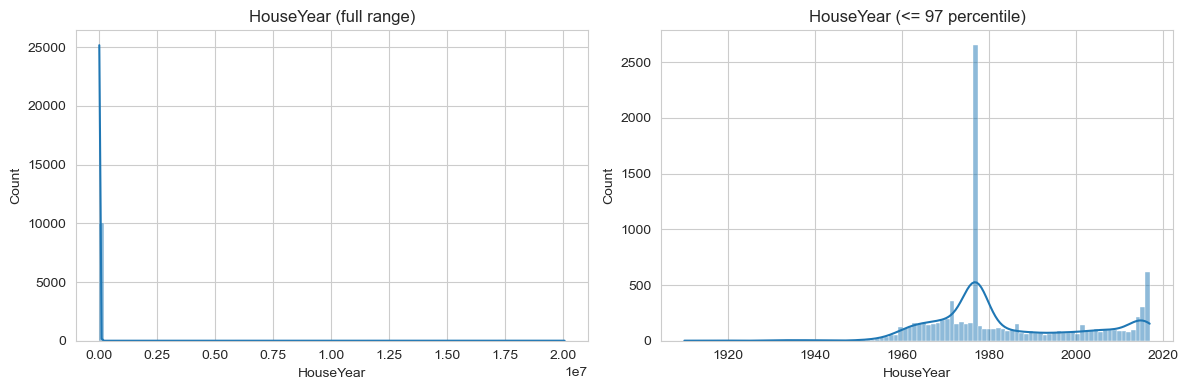

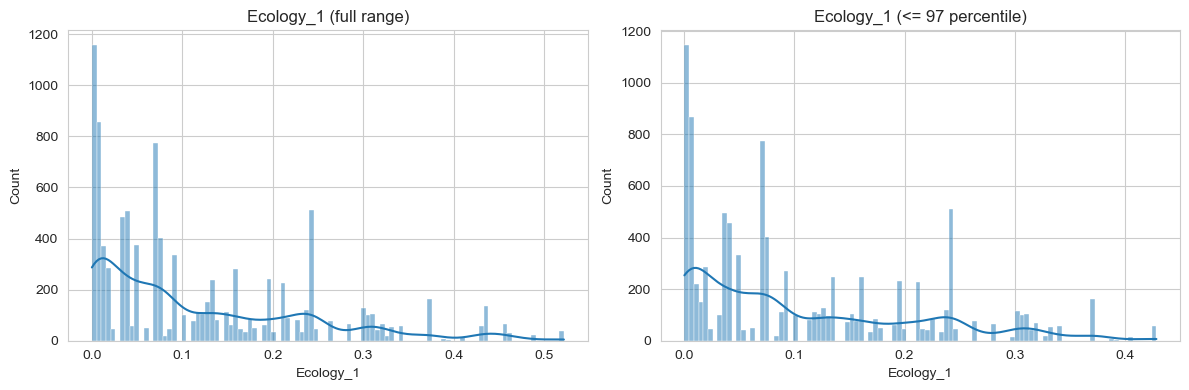

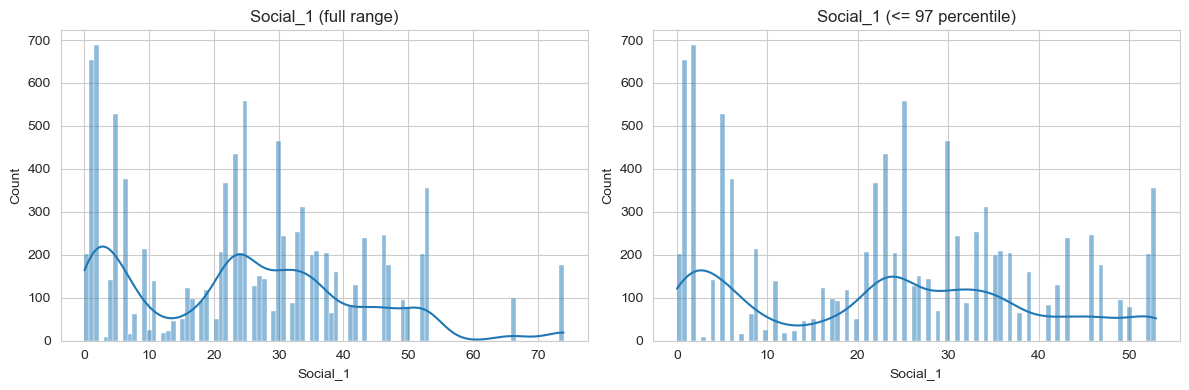

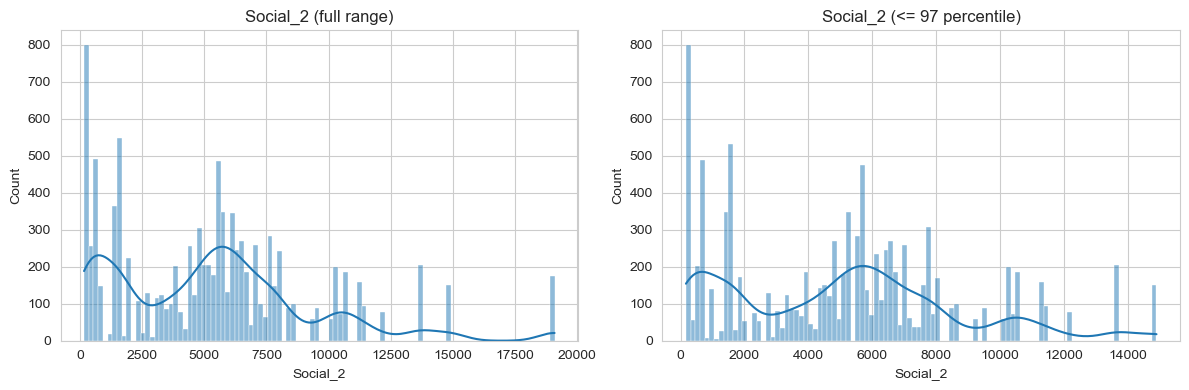

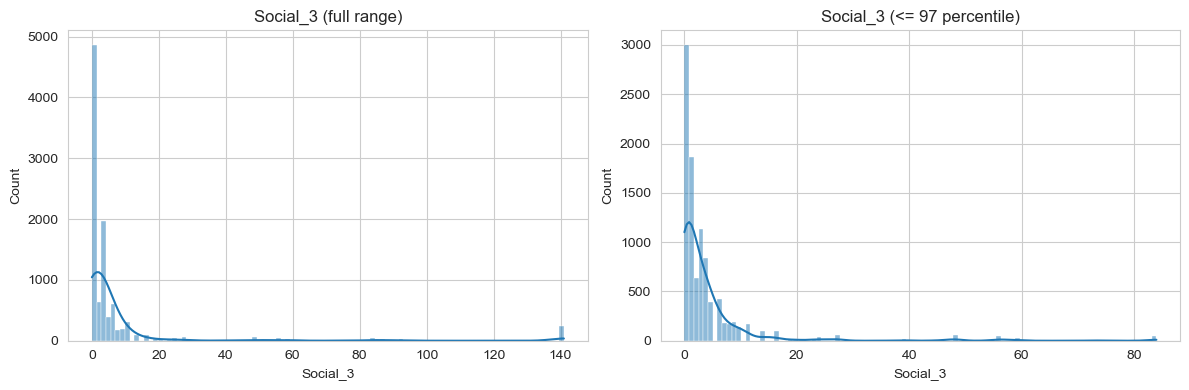

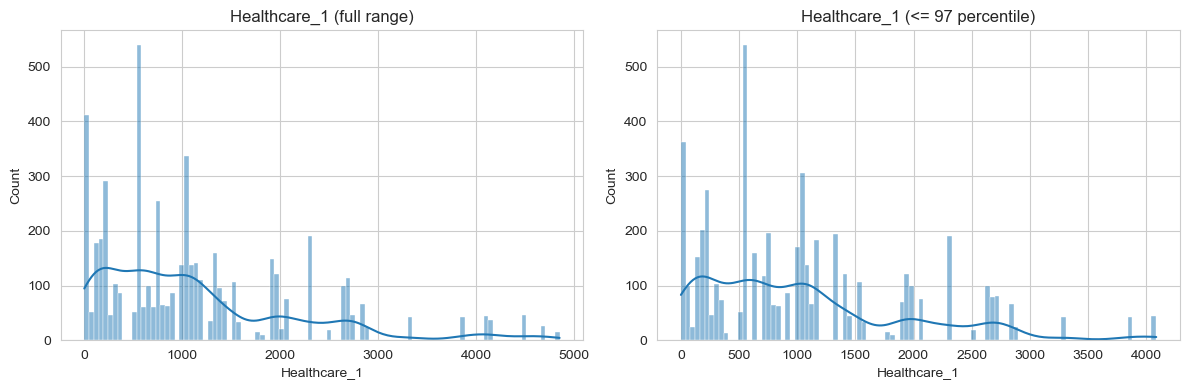

In [64]:
plot_numeric_distributions_with_quantile(df, numeric_cols)

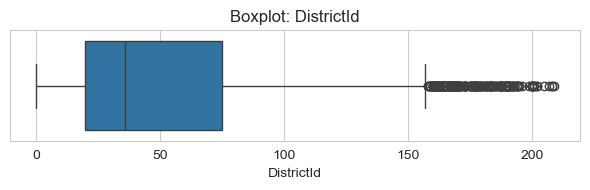

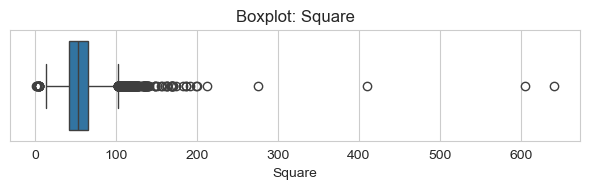

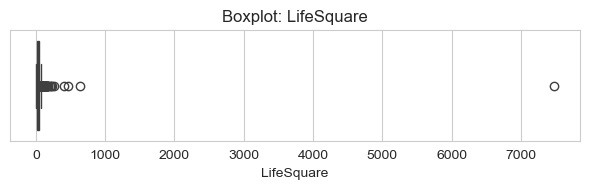

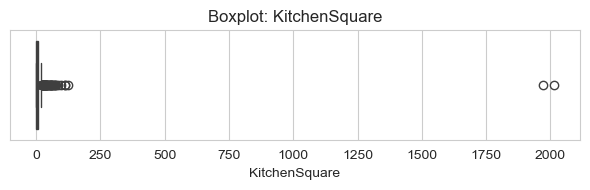

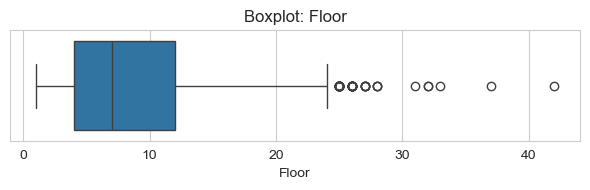

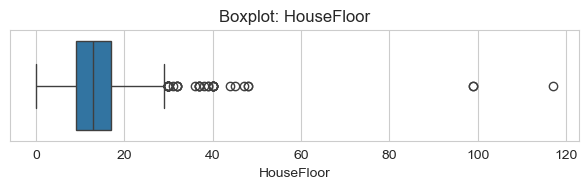

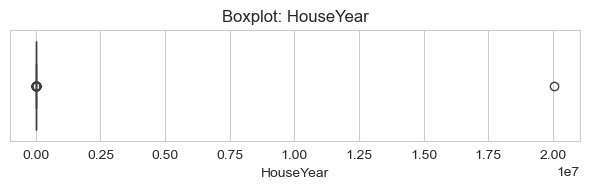

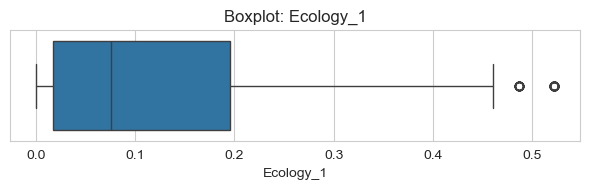

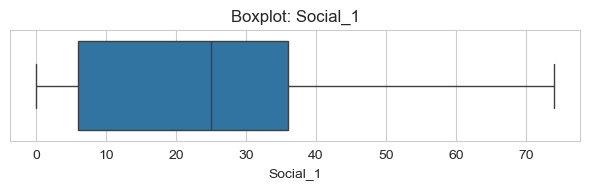

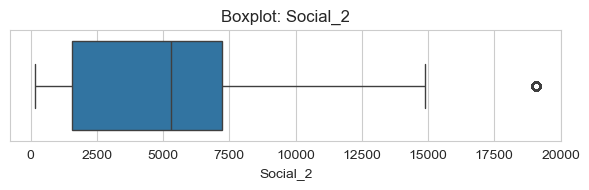

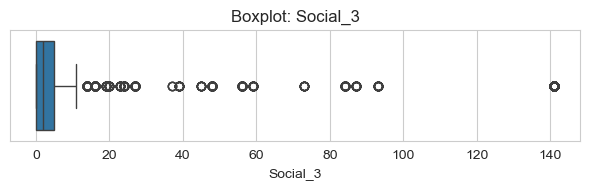

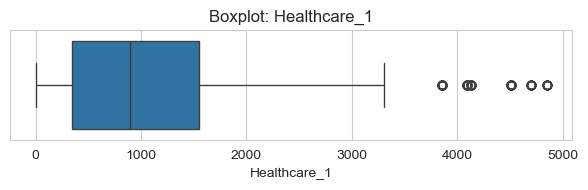

In [65]:
for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()


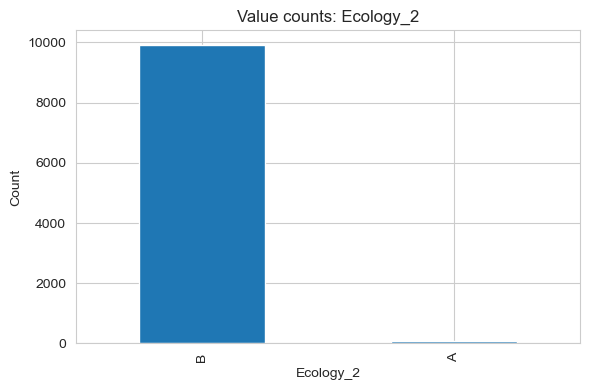

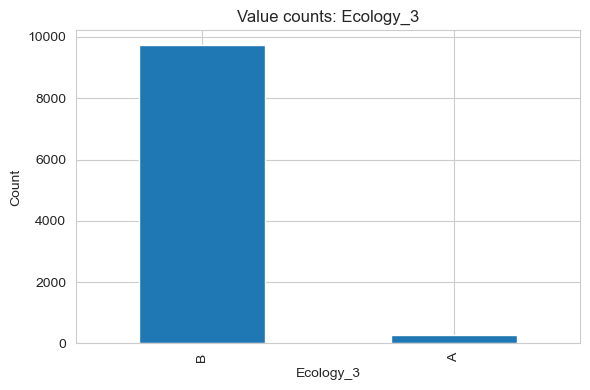

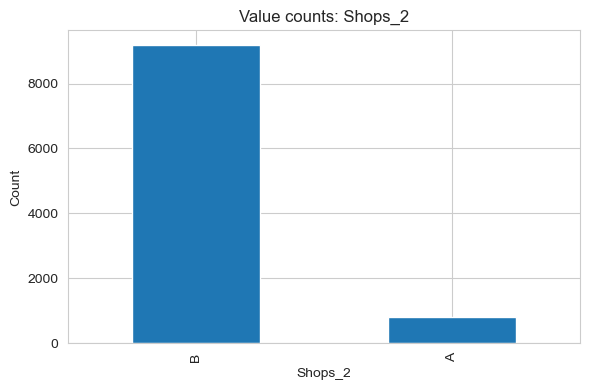

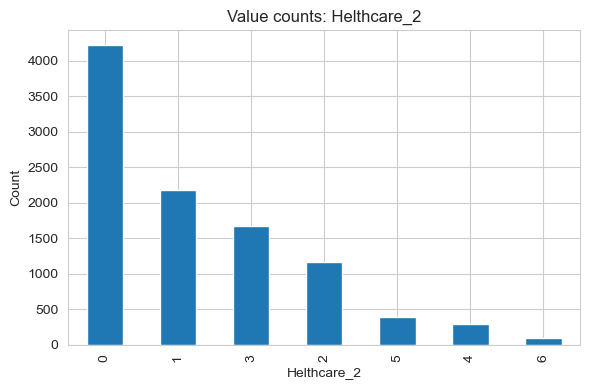

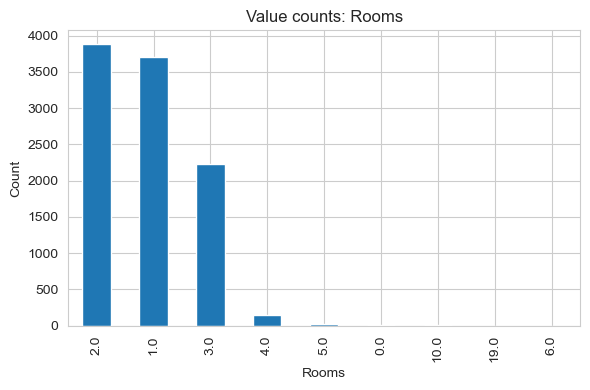

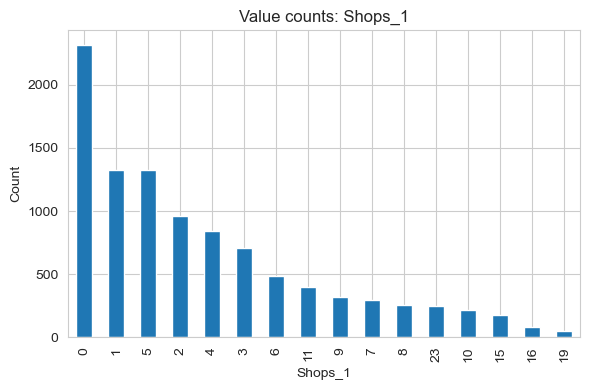

In [66]:
MAX_CATEGORIES = 20

for col in categorical_cols:
    vc = df[col].value_counts(dropna=False)

    if vc.shape[0] > MAX_CATEGORIES:
        print(f"{col}: слишком много категорий ({vc.shape[0]}), пропускаем график")
        continue

    plt.figure(figsize=(6, 4))
    vc.plot(kind="bar")
    plt.title(f"Value counts: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [67]:
categorical_cols = categorical_cols.drop(["Ecology_2", "Ecology_3"])

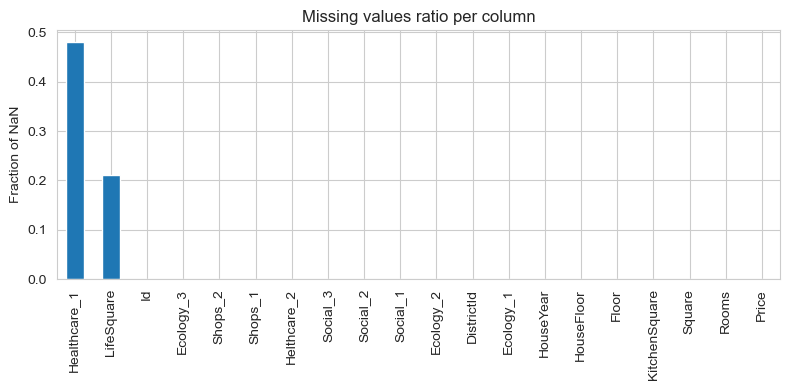

In [68]:
na_ratio = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
na_ratio.plot(kind="bar")
plt.title("Missing values ratio per column")
plt.ylabel("Fraction of NaN")
plt.tight_layout()
plt.show()


In [69]:
def fill_numeric_with_median(df, numeric_cols):
    """
    df: pandas DataFrame
    numeric_cols: список числовых колонок

    Возвращает:
    - новый DataFrame
    - dict с медианами {col: median}
    """
    df = df.copy()
    medians = {}

    for col in numeric_cols:
        if col not in df.columns:
            continue

        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        medians[col] = median_value

    return df, medians


In [70]:
df, medians = fill_numeric_with_median(
    df,
    ["Healthcare_1"]
)

In [71]:
# считает среднее соотношение Общей площади и жилой, затем заполняет пропуски в LifeSquare

def fill_lifesquare_from_square(
    df,
    square_col="Square",
    lifesquare_col="LifeSquare",
    min_square=10,
):
    """
    Заполняет LifeSquare на основе зависимости LifeSquare ~ k * Square

    - k считается как медиана LifeSquare / Square
      по строкам, где оба значения есть
    - заполняются только NaN в LifeSquare
    """

    df = df.copy()

    mask_valid = (
        df[square_col].notna()
        & df[lifesquare_col].notna()
        & (df[square_col] > min_square)
    )

    ratios = df.loc[mask_valid, lifesquare_col] / df.loc[mask_valid, square_col]
    k = ratios.median()

    fill_mask = df[lifesquare_col].isna() & df[square_col].notna()
    df.loc[fill_mask, lifesquare_col] = df.loc[fill_mask, square_col] * k

    return df, k


In [72]:
df, life_ratio = fill_lifesquare_from_square(df)

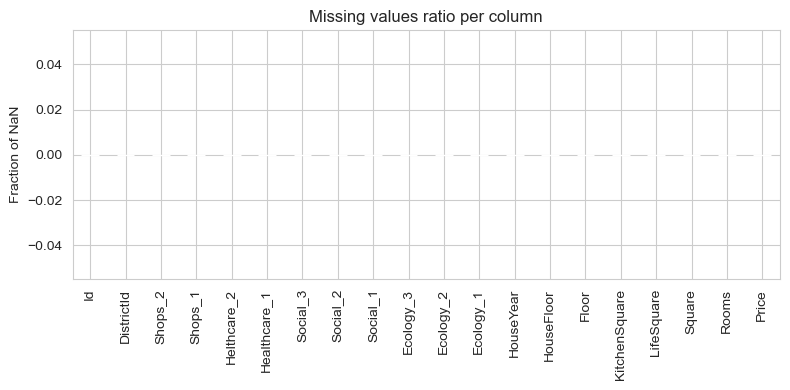

In [78]:
na_ratio = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
na_ratio.plot(kind="bar")
plt.title("Missing values ratio per column")
plt.ylabel("Fraction of NaN")
plt.tight_layout()
plt.show()

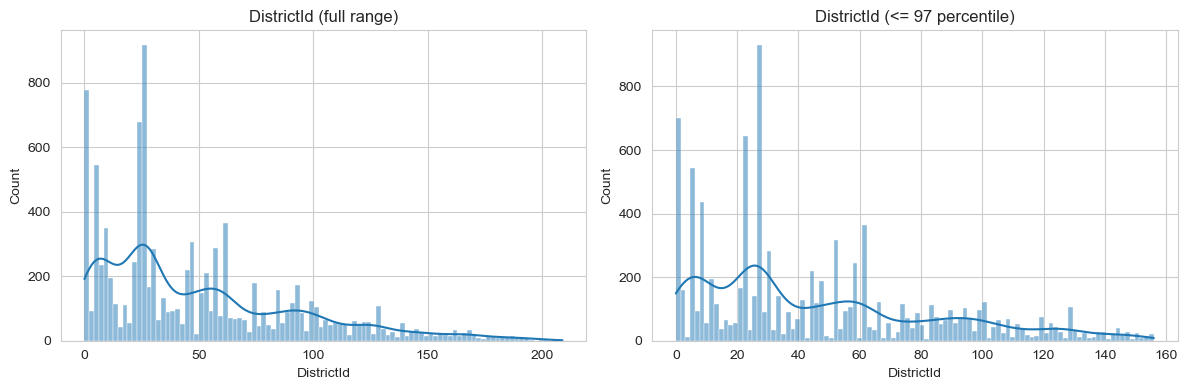

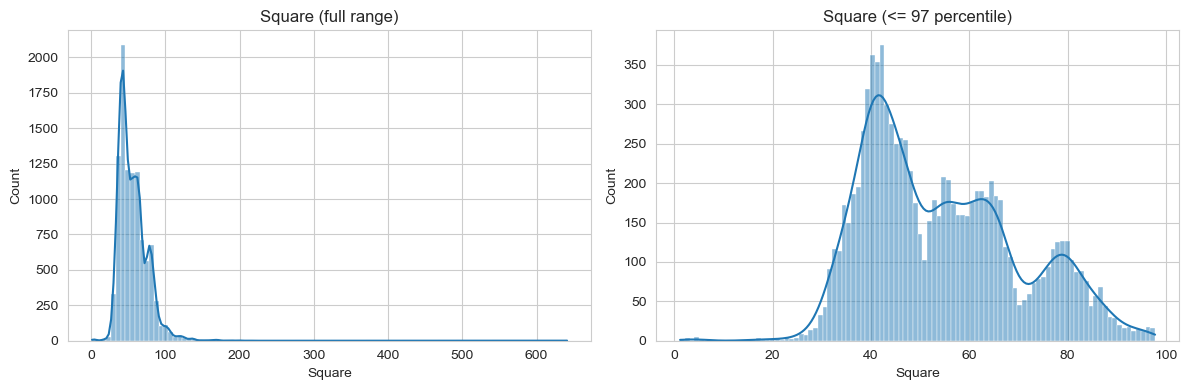

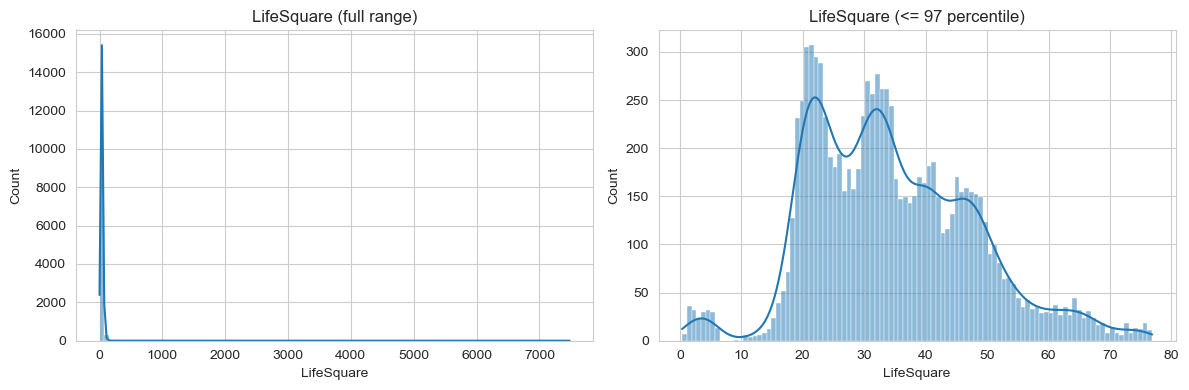

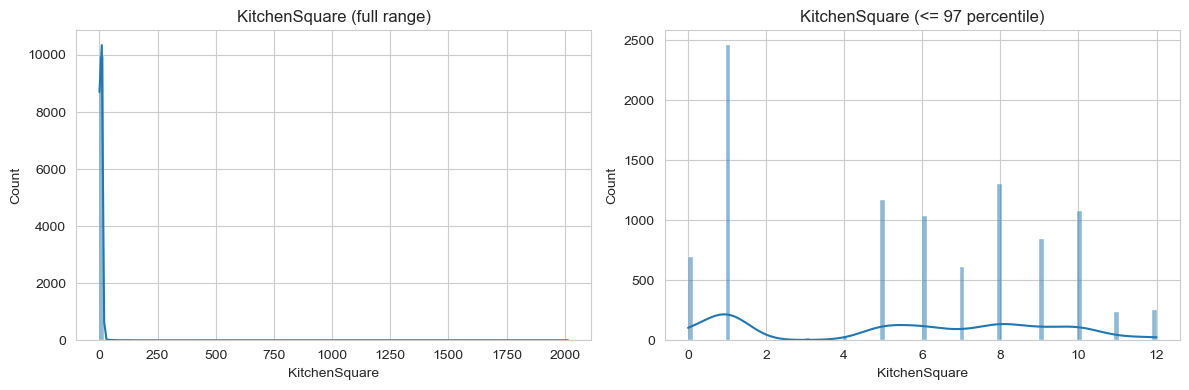

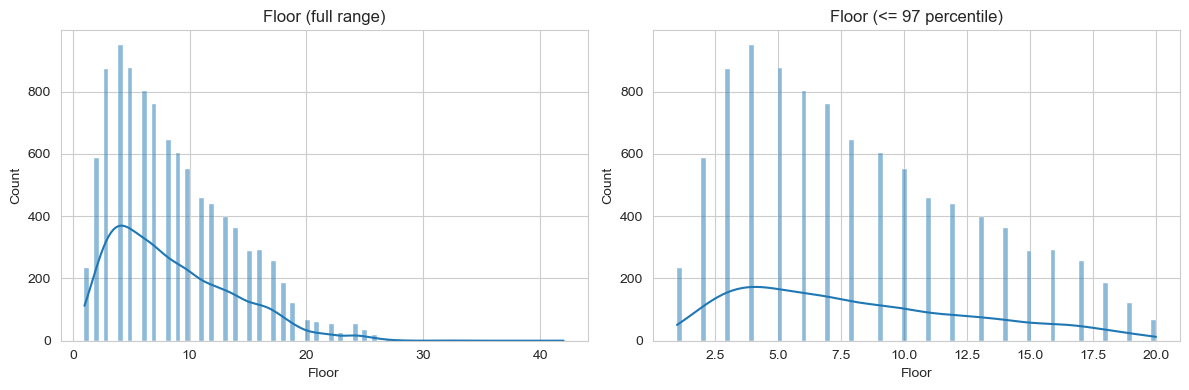

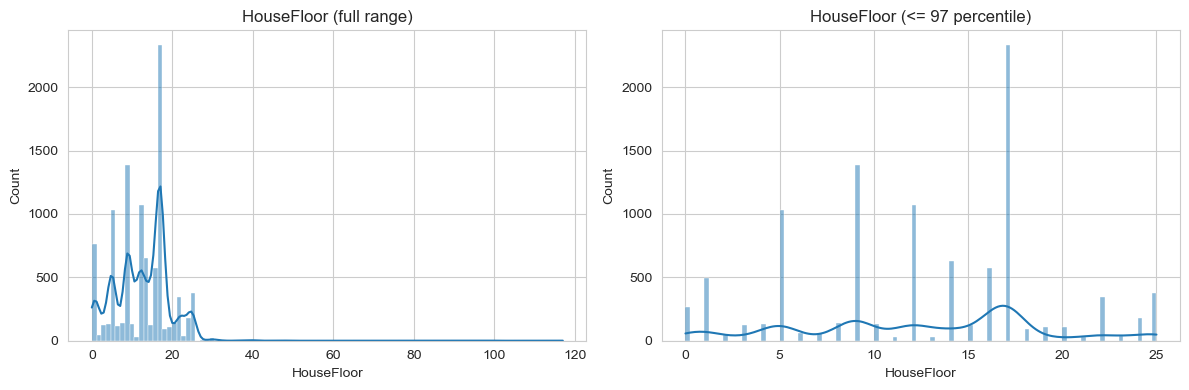

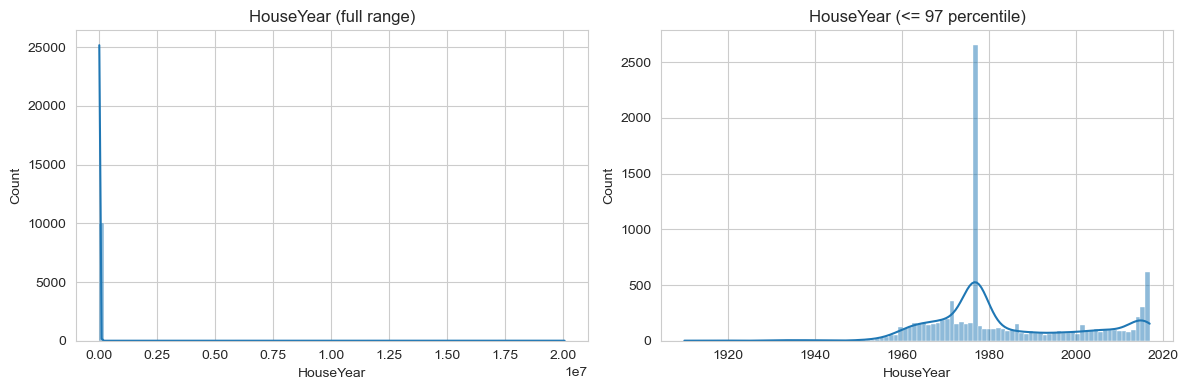

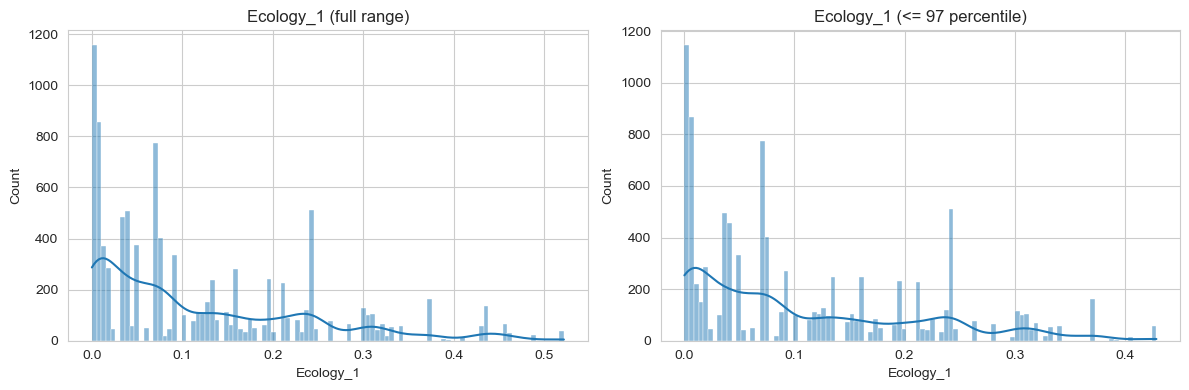

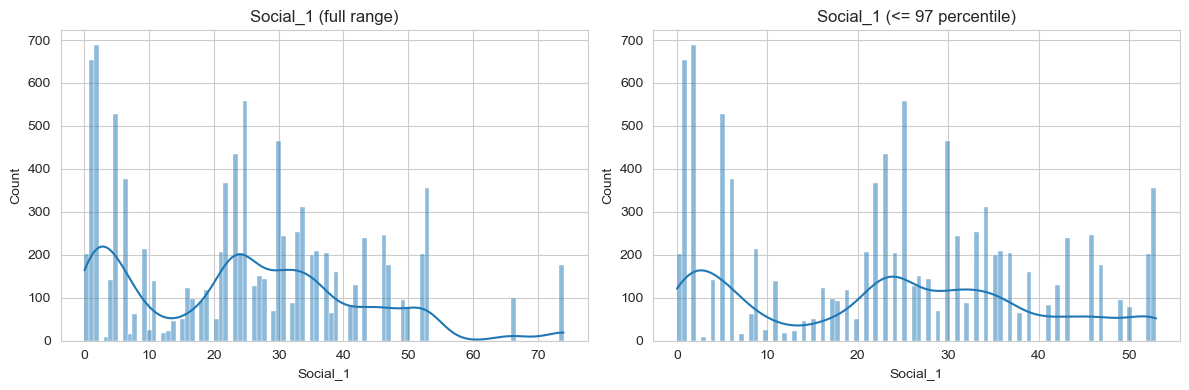

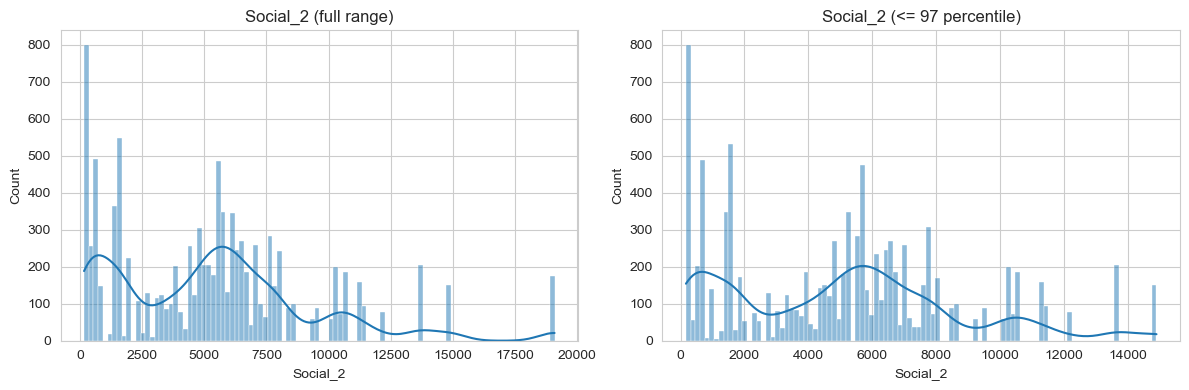

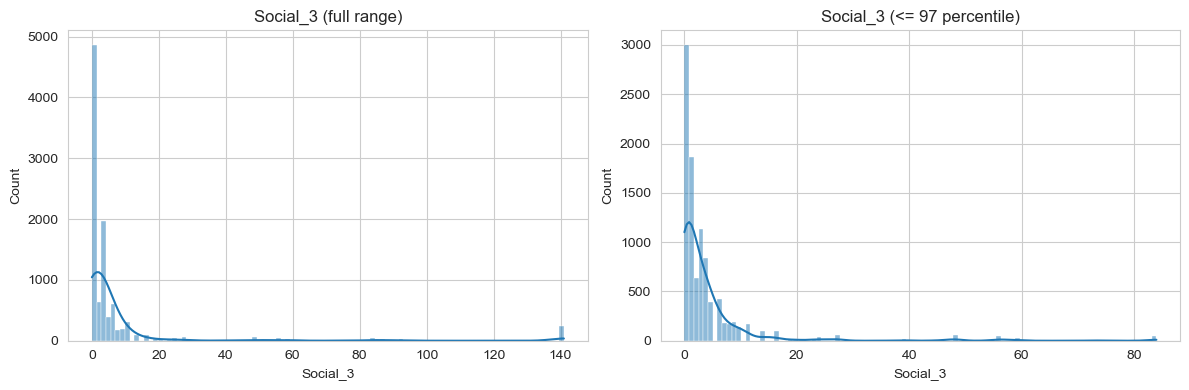

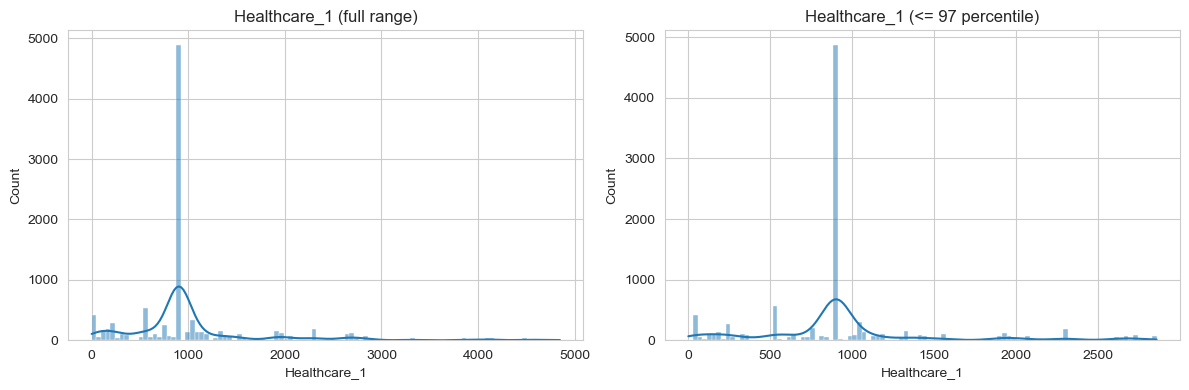

In [76]:
plot_numeric_distributions_with_quantile(df, numeric_cols)

In [79]:
# давит экстремальные значения с двух сторон в указанных колонках к указанному перцентилю 
def clip_numeric_columns(df, numeric_cols, clip_rules):
    """
    df: pandas DataFrame
    numeric_cols: list[str] — все колонки, которые считаются числовыми
    clip_rules: dict вида
        {
            "total_square": (0.01, 0.99),
            "kitchen_square": (0.01, 0.95),
        }

    Возвращает:
    - новый DataFrame
    - dict с границами клиппинга {col: (low, high)}
    """
    df = df.copy()
    clip_bounds = {}

    numeric_cols = [c for c in numeric_cols if c in df.columns]

    for col in numeric_cols:
        if col not in clip_rules:
            continue  # числовая, но клиппить не надо

        q_low, q_high = clip_rules[col]

        low = df[col].quantile(q_low)
        high = df[col].quantile(q_high)

        df[col] = df[col].clip(lower=low, upper=high)
        clip_bounds[col] = (low, high)

    return df, clip_bounds


In [81]:
DEFAULT_TOP_QUANTILE = 0.97

CLIP_RULES = {
    "Square": (0.01, DEFAULT_TOP_QUANTILE),
    "LifeSquare": (0.01, DEFAULT_TOP_QUANTILE),
    "KitchenSquare": (0.01, DEFAULT_TOP_QUANTILE),
    "HouseYaer": (0.01, DEFAULT_TOP_QUANTILE),
}

df, clip_bounds = clip_numeric_columns(df, numeric_cols, CLIP_RULES)

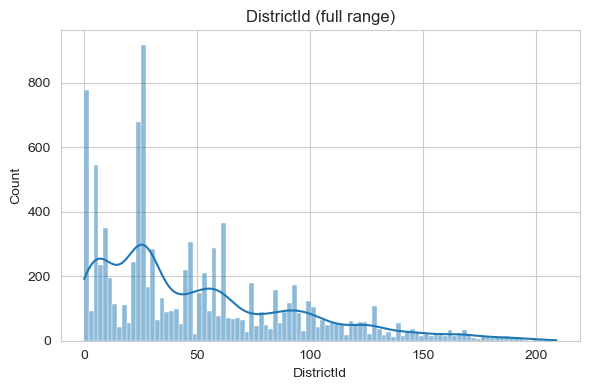

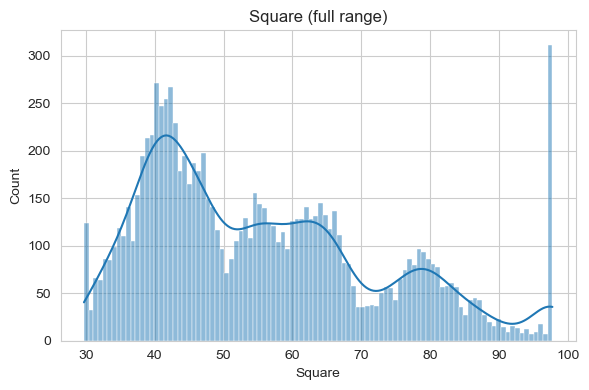

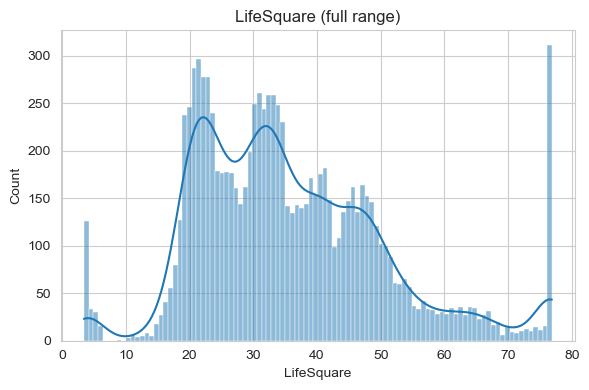

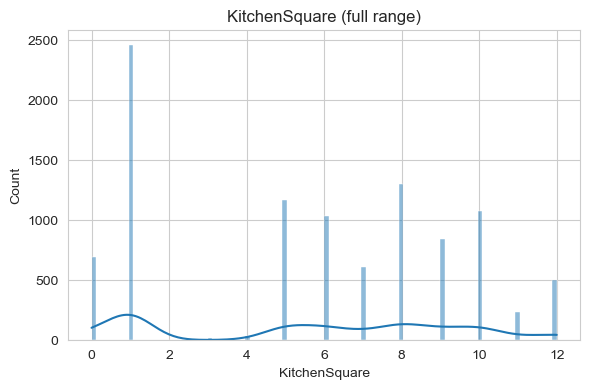

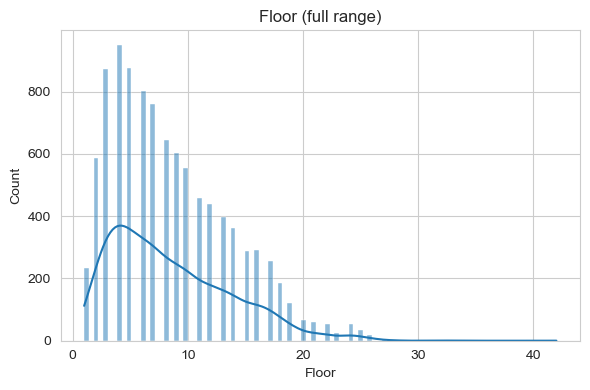

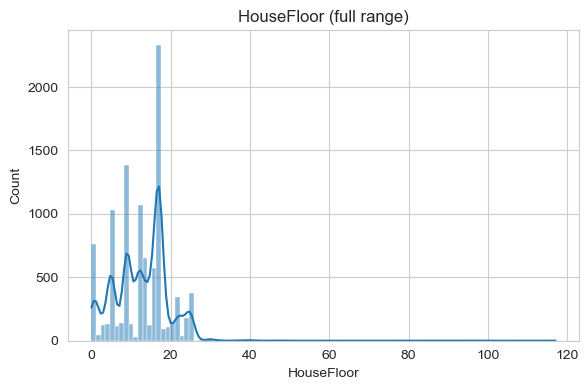

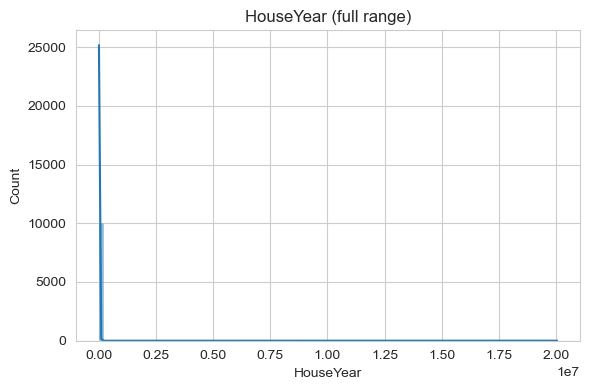

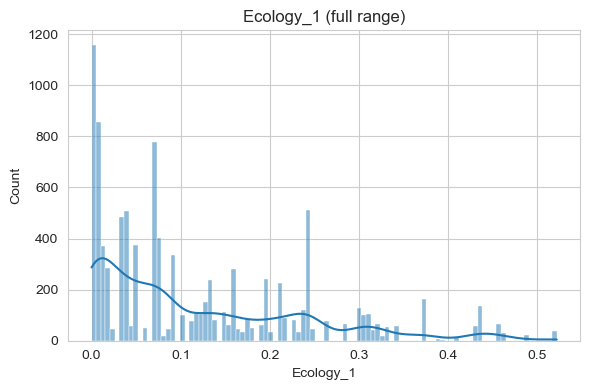

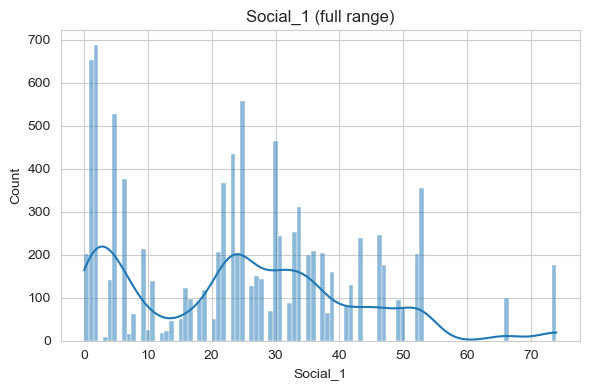

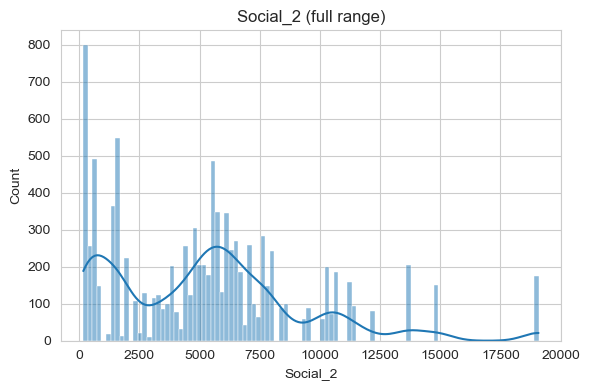

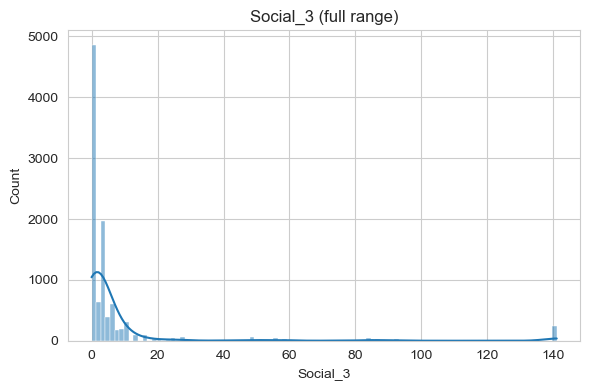

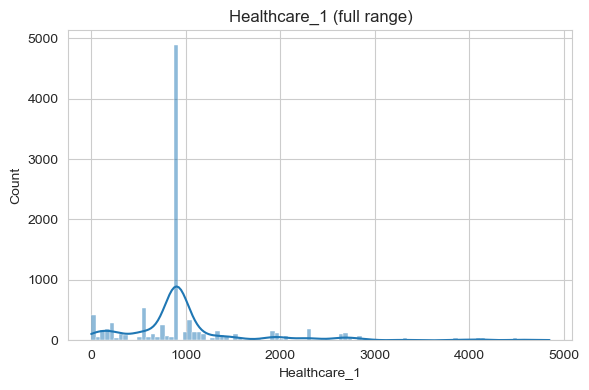

In [82]:
plot_numeric_distributions(df, numeric_cols)